## How Fast Do We Forget? The Rise and Fall of the Epstein Files 

When I think about trends, I’m reminded of the history course I’m taking this semester, where we study moments that once consumed public attention for months, if not years. Today, that kind of sustained focus feels almost impossible. We are constantly flooded with information from every direction, and as a result, even major events struggle to hold our attention. This is compounded by a broader decline in trust in institutions and elites, which further weakens our investment in the headlines we encounter. Our attention spans are already short, and in many ways, we have become desensitized to the constant stream of breaking news.

I found myself wondering recently: if something like Watergate happened today, would anyone really care? This question led me to explore search interest surrounding the Epstein files, which initially appeared to be a major flashpoint. However, as the data reveals, even this moment of intense public attention was remarkably short-lived, rising quickly and fading just as fast. By late April, interest had already dropped to near-baseline levels, suggesting that even the most high-profile stories struggle to maintain lasting public engagement.

In [14]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('data/epstein_since2004.csv')
df.head()

,Time,epstein
0,2004-01-01,1
1,2004-02-01,1
2,2004-03-01,1
3,2004-04-01,1
4,2004-05-01,1


Since 2004, search interest in Epstein remained consistently low, near zero for most of the period, until a dramatic spike around 2019. This surge corresponds with his arrest in July 2019 on federal sex trafficking charges, followed by his death in jail in August, which brought widespread public attention to the case.

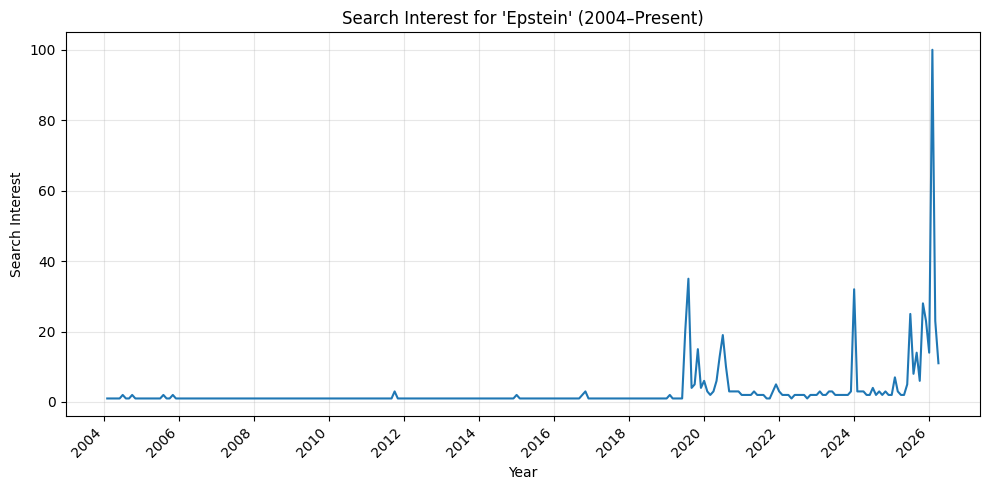

In [22]:
df_long = pd.read_csv('data/epstein_since2004.csv')

# clean
df_long = df_long.iloc[1:]
df_long.columns = ['date', 'search_interest']

df_long['date'] = pd.to_datetime(df_long['date'])
df_long['search_interest'] = pd.to_numeric(df_long['search_interest'])

# plot
import matplotlib.dates as mdates

plt.figure(figsize=(10,5))

plt.plot(df_long['date'], df_long['search_interest'])

plt.title("Search Interest for 'Epstein' (2004–Present)")
plt.xlabel("Year")
plt.ylabel("Search Interest")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))  # every 2 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Figure 1: Long-term Google search interest for “Epstein” since 2004. The data shows that public attention is largely dormant, punctuated by sharp spikes corresponding to major news events.

In [19]:
df = pd.read_csv('data/epstein_5years.csv')
df.head()

,Time,epstein
0,2021-05-01,3
1,2021-06-01,2
2,2021-07-01,2
3,2021-08-01,2
4,2021-09-01,1


Due to limitations within Google Trends, I was unable to isolate a seven-year window that would have captured the 2019 spike alongside the more recent spikes in 2024 and 2026. Instead, I focused on the past five years, which still reveals important patterns in public attention. Within this period, a noticeable spike occurs in early 2024, driven by the release of Epstein-related court documents that identified associates, contacts, and witnesses. While this spike is significant, it is notably smaller in magnitude compared to the surge observed in 2026, suggesting that not all high-profile developments generate the same level of sustained public interest.

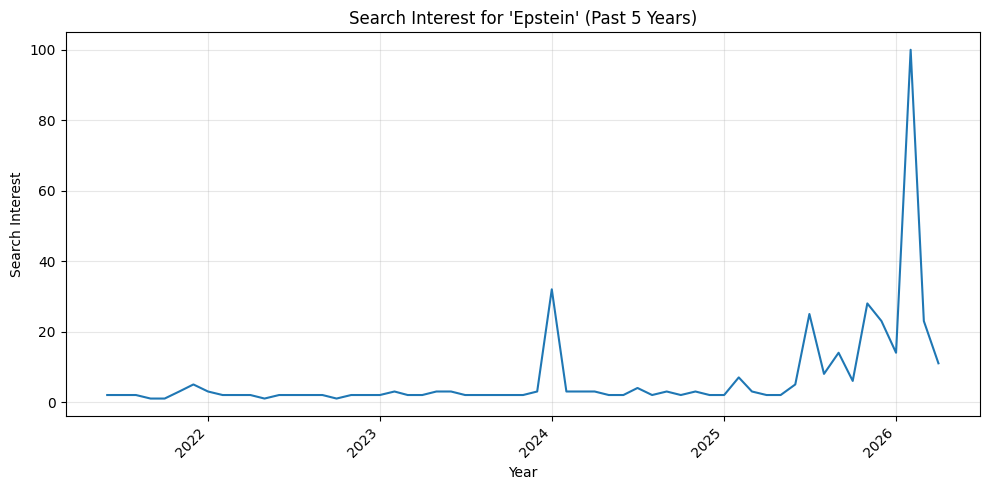

In [25]:
df_5yr = pd.read_csv('data/epstein_5years.csv')

# clean
df_5yr = df_5yr.iloc[1:]
df_5yr.columns = ['date', 'search_interest']

df_5yr['date'] = pd.to_datetime(df_5yr['date'])
df_5yr['search_interest'] = pd.to_numeric(df_5yr['search_interest'])

# plot
plt.figure(figsize=(10,5))

plt.plot(df_5yr['date'], df_5yr['search_interest'])

plt.title("Search Interest for 'Epstein' (Past 5 Years)")
plt.xlabel("Year")
plt.ylabel("Search Interest")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))  # every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Figure 2: Search interest over the past five years highlights repeated spikes in attention, each followed by a rapid decline, reinforcing the short-lived nature of public interest.

In [29]:
df = pd.read_csv('data/epstein_1year.csv')

In [6]:
df.head()

,Time,epstein
0,2025-04-27,1
1,2025-05-04,1
2,2025-05-11,1
3,2025-05-18,1
4,2025-05-25,1


The one-year view highlights just how abrupt this pattern is: interest surges rapidly and then declines almost immediately. When zooming in further to the past three months and isolating the peak, the dynamics become even more striking. The spike resembles a bubble of attention, rapidly expanding in response to a major event before collapsing just as quickly

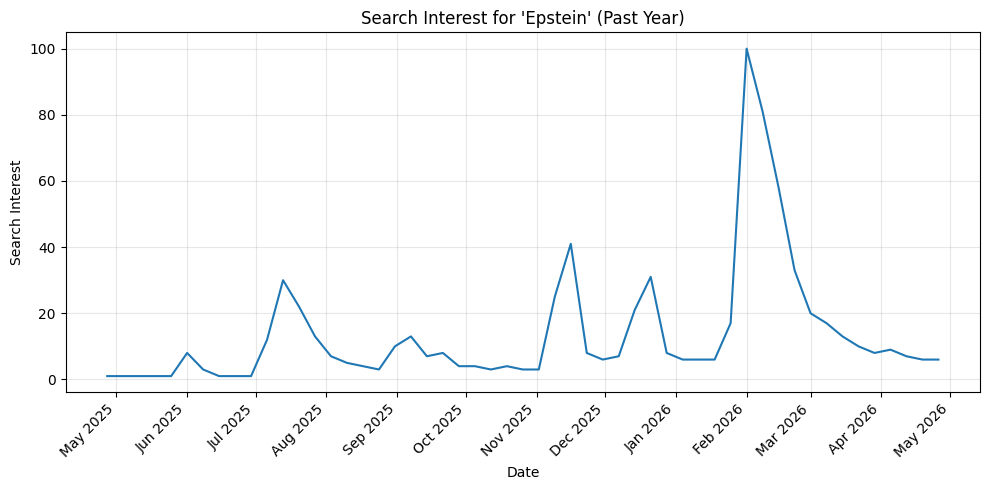

In [31]:
import matplotlib.dates as mdates

df['Time'] = pd.to_datetime(df['Time'])

plt.figure(figsize=(10,5))

plt.plot(df['Time'], df['epstein'])

plt.title("Search Interest for 'Epstein' (Past Year)")
plt.xlabel("Date")
plt.ylabel("Search Interest")

# 👇 FIXED AXIS
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
df = pd.read_csv('data/epstein_3mo.csv')

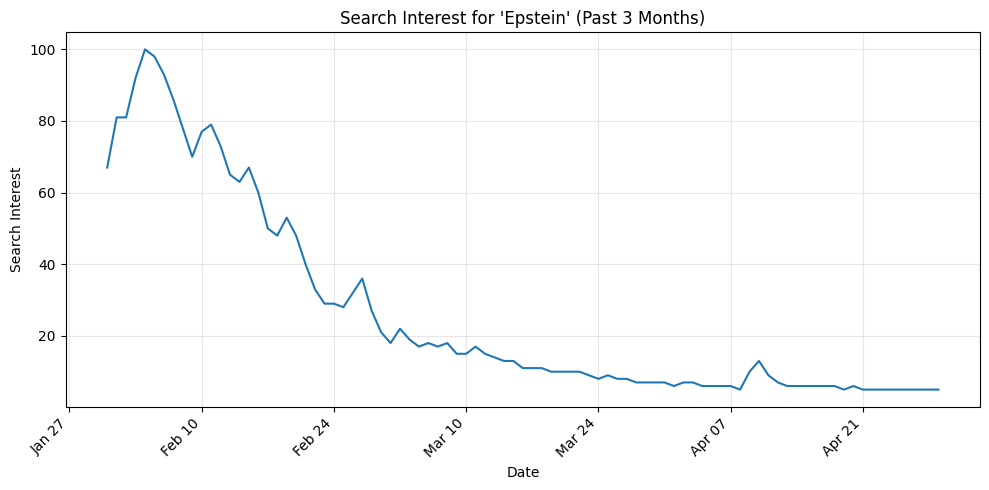

In [35]:
# load data
df_3m = pd.read_csv('data/epstein_3mo.csv')

# clean (Google Trends format)
df_3m = df_3m.iloc[1:]
df_3m.columns = ['Time', 'epstein']

# fix types
df_3m['Time'] = pd.to_datetime(df_3m['Time'])
df_3m['epstein'] = pd.to_numeric(df_3m['epstein'])

# plot
plt.figure(figsize=(10,5))

plt.plot(df_3m['Time'], df_3m['epstein'])

plt.title("Search Interest for 'Epstein' (Past 3 Months)")
plt.xlabel("Date")
plt.ylabel("Search Interest")

# 👇 correct formatting for short window
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

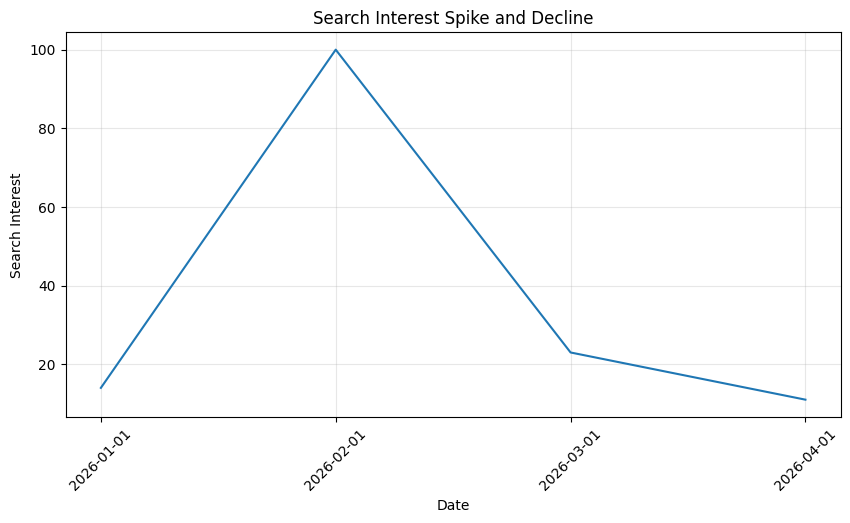

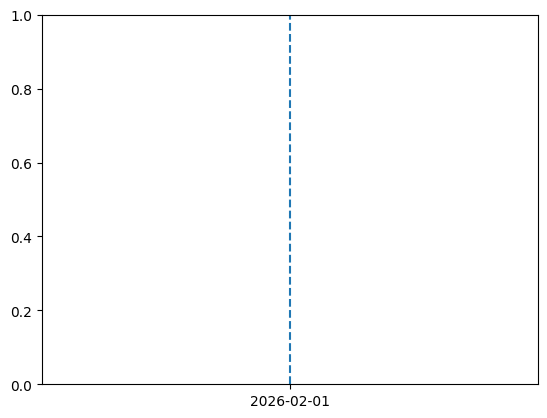

In [28]:
df_zoom = df[df['Time'] >= '2026-01-01']

plt.figure(figsize=(10,5))
plt.plot(df_zoom['Time'], df_zoom['epstein'])

plt.title("Search Interest Spike and Decline")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()
plt.axvline(x='2026-02-01', linestyle='--')

Rather than maintaining sustained engagement with ongoing issues, public attention appears to be driven by novelty and immediacy, rising sharply in response to breaking news and fading once the initial shock passes. This pattern is evident in the rapid decline following the February peak, where search interest drops from its maximum value of 100 to nearly half within a single week and continues to fall steadily thereafter, highlighting the short-lived nature of public engagement.

Taken together, these patterns reveal a consistent dynamic across time scales: public attention is not sustained, but instead driven by short-lived bursts of interest. Whether viewed over decades, years, or even weeks, attention spikes rapidly in response to major events and fades just as quickly. In a media environment defined by constant information and rapid turnover, even the most high-profile stories struggle to maintain lasting engagement. Ultimately, this suggests that public attention is less a reflection of enduring concern and more a reaction to momentary, attention-grabbing events.